### Disclaimer

This notebook was developed as a precursor to the project's DGI model, meaning it lacks data it was trained on, this old version is being tested with the transductive method but only for two projects/ graphs

## Preprocessing the graphs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import os
import gc
import json
import hashlib
from pathlib import Path
import pickle
from torch_geometric.data import Data
from transformers import AutoTokenizer, AutoModel
import glob
import re

In [6]:
APPDATA = os.environ.get("APPDATA", str(Path.home() / "AppData" / "Roaming"))
BASE_DIR = Path(APPDATA) / "log-a-priori-desktop-shell"
CODEBERT_MAX_LEN = 512 # model's max token limit

In [7]:
def discover_graph_jsons(base_dir: Path):
    return sorted(base_dir.glob("*/analysis/ts-code-graph.json"))

def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

graph_paths = discover_graph_jsons(BASE_DIR)
print(f"Found {len(graph_paths)} graph JSON files under {BASE_DIR}")

rows = []
for p in graph_paths:
    try:
        obj = load_json(p)
        nodes = obj.get("graph", {}).get("nodes", [])
        edges = obj.get("graph", {}).get("edges", [])
        summary = obj.get("summary", {})
        rows.append({
            "project_file": str(p),
            "generatedAt": obj.get("generatedAt"),
            "nodes": len(nodes),
            "edges": len(edges),
            "functions": summary.get("functions"),
            "call_edges": summary.get("callEdges"),
            "uses_edges": summary.get("usesEdges"),
            "cross_file_calls": summary.get("crossFileCallEdges"),
            "cross_file_uses": summary.get("crossFileUsesEdges"),
        })
    except Exception as e:
        rows.append({"project_file": str(p), "error": str(e)})

overview = pd.DataFrame(rows)
display(overview)
node_df = pd.DataFrame(nodes)

edge_df = pd.DataFrame(edges)
display(edge_df.groupby([c for c in ["kind", "scope"] if c in edge_df.columns]).size().reset_index(name="count").sort_values("count", ascending=False))

Found 1 graph JSON files under C:\Users\alice\AppData\Roaming\log-a-priori-desktop-shell


,project_file,generatedAt,nodes,edges,functions,call_edges,uses_edges,cross_file_calls,cross_file_uses
0,C:\Users\alice\AppData\Roaming\log-a-priori-de...,2026-04-28T07:07:45.738Z,373,1278,373,599,679,392,471


,kind,scope,count
2,USES,cross-file,471
0,CALLS,cross-file,392
3,USES,in-file,208
1,CALLS,in-file,207


### Tokenization

count     373.000000
mean      262.093834
std       485.993190
min        17.000000
25%        81.000000
50%       133.000000
75%       266.000000
max      6937.000000
Name: token_len, dtype: float64
Over 512 tokens: 40 / 373


,kind,simpleName,file,token_len,code_len
337,function,KnowledgeGraphCanvas,workflow-app/features/knowledge-graph/componen...,6937,29124
26,function,run,workflow-app/scripts/analyze-recursion.js,3747,17472
369,function,WebhookEventsList,workflow-app/features/webhook-events/component...,2324,9128
322,lambda,CreateCredentialDialog,workflow-app/features/credentials/components/c...,2103,9615
361,lambda,ProjectSetupTabs,workflow-app/features/projects/components/proj...,1705,6406
145,function,Calendar,workflow-app/components/ui/calendar.tsx,1577,5674
371,function,githubWebhook,workflow-app/github-webhook/src/functions/gith...,1278,5097
233,function,Sidebar,workflow-app/components/ui/sidebar.tsx,1184,3671
339,function,KnowledgeGraphRootDirectory,workflow-app/features/knowledge-graph/componen...,1171,5286
156,function,ChartTooltipContent,workflow-app/components/ui/chart.tsx,1146,4606


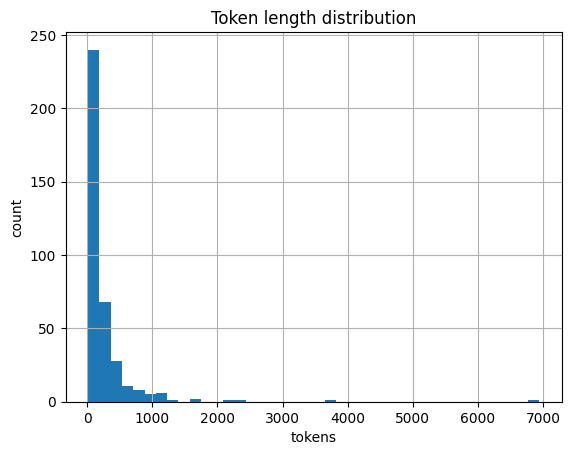

7617

In [8]:
code_lengths = node_df["code"].fillna("").astype(str).map(len)
node_df = node_df.assign(code_len=code_lengths)

tokenizer = AutoTokenizer.from_pretrained("microsoft/unixcoder-base")

def token_len(code):
    return len(tokenizer(code, return_tensors=None, truncation=False)["input_ids"])

node_df = node_df.assign(token_len=node_df["code"].fillna("").astype(str).map(token_len)) # apply token_len to code
print(node_df["token_len"].describe())
print(f"Over {CODEBERT_MAX_LEN} tokens:", int((node_df["token_len"] > CODEBERT_MAX_LEN).sum()), f"/ {len(node_df)}")
long_nodes_df = node_df[node_df["token_len"] > CODEBERT_MAX_LEN].sort_values("token_len", ascending=False)
display(long_nodes_df[["kind", "simpleName", "file", "token_len", "code_len"]].head(20))

if plt is not None:
    plt.figure()
    node_df["token_len"].hist(bins=40)
    plt.title("Token length distribution")
    plt.xlabel("tokens")
    plt.ylabel("count")
    plt.show()

del tokenizer

torch.cuda.empty_cache()
gc.collect()

### Chunking

In [9]:
models = {
    "CodeBERT (original)": "microsoft/codebert-base",
    "CodeBERT (fine-tuned)": "mchochlov/codebert-base-cd-ft",
    "UniXcoder": "microsoft/unixcoder-base",
}

def load_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    if torch.cuda.is_available():
        model.cuda()
        print("gpu")
    else:
        print("cpu")
    return tokenizer, model

In [10]:
CHUNK_OVERLAP = 128 # overlap between chunks (tokens), in order to not separte meaningful code blocks which would otherwise be split into chunks with no info about the missing part

# this version of embedding creation won't load cached embeddings
def embed_token_chunk(token_ids, attention_mask, model): # computing mean pooled embedding for a token chunk
    input_ids = torch.tensor([token_ids], dtype=torch.long) # transforming a chunk of token ids to a tensor
    attn_mask = torch.tensor([attention_mask], dtype=torch.long) # corresponding attention mask
    if torch.cuda.is_available():
        input_ids = input_ids.cuda()
        attn_mask = attn_mask.cuda()
    with torch.no_grad(): # no need for gradients at the inference step
        outputs = model(input_ids, attention_mask=attn_mask) # passing through codebert, 768 is the output dimension of the codebert model
    
    # mean pooling over token
    masked = outputs.last_hidden_state * attn_mask.unsqueeze(-1) # (1,512,768), because we multiply attention mask with embeddings outputs.last_hidden_state (ignoring padding) => (batch_size, sequence_length, hidden_size) = (1, 512, 768)
    sum_emb = masked.sum(dim=1) # (1,768), summing over the multiplication (only real tokens contribute)
    real_count = attn_mask.sum(dim=1) # (1,), counting real tokens

    emb = sum_emb / real_count.unsqueeze(-1) # (1,768), averaging

    return emb.squeeze().cpu().numpy().astype(np.float32)

def get_code_embedding(code, tokenizer, model, display_flag=True, max_len=CODEBERT_MAX_LEN, overlap=CHUNK_OVERLAP): # return the code embedding for a function and checks if the token count is exceeded, then splits into overlapping chunks using a sliding window
    encoding = tokenizer(code, return_tensors="pt", truncation=False, padding=False) # tokenize full code (without truncation)
    input_ids = encoding["input_ids"][0].tolist()
    total_tokens = len(input_ids)
    if (display_flag): print(f"\tToken count: {total_tokens}")
    
    if total_tokens <= max_len: # if respecting the limit, embed the full code
        inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=max_len) # transforming to tokens, padded to length CODEBERT_MAX_LEN
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        
        emb = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy().astype(np.float32)
        num_chunks = 1
        if (display_flag): print(f"Direct embedding: 1 chunk")
    else:
        chunk_embeddings = [] # chunking is needed
        stride = max_len-overlap
        num_chunks = (total_tokens-max_len+stride-1) // stride + 1
        if (display_flag): print(f"\tChunking with stride={stride}, overlap={overlap}: {num_chunks} chunks")

        for chunk_index, start in enumerate(range(0, total_tokens, stride)):
            end = min(start + max_len, total_tokens)
            chunk_ids = input_ids[start:end]
            attn_mask = [1] * len(chunk_ids)
            pad_len = 0
            if len(chunk_ids) < max_len: # pad only the last chunk to CODEBERT_MAX_LEN if it is needed
                pad_len = max_len - len(chunk_ids)
                chunk_ids.extend([tokenizer.pad_token_id] * pad_len)
                attn_mask.extend([0] * pad_len)
            if (display_flag): print(f"\t\tChunk {chunk_index}: tokens [{start}:{end}] (len={len(chunk_ids)-pad_len}, pad={pad_len})") # overlapping chunks ensure that patterns near chunk boundaries are seen in two chunks, reducing information loss

            emb = embed_token_chunk(chunk_ids, attn_mask, model)
            chunk_embeddings.append(emb)
        
        emb = np.mean(chunk_embeddings, axis=0) # average chunk embeddings
    return emb # every token’s representation is a 768 dimensional vector for codebert

print(f"Comparing {len(long_nodes_df.head(3))} long functions across models")
results = []
for name, model_id in models.items():
    tokenizer, model = load_model(model_id)
    print(f"\n\n\nTokenizer and model loaded for {name}")
    for idx, row in long_nodes_df.head(3).iterrows(): # for each function, compute embedding without caching for comparison
        func_name = row["simpleName"]
        file_name = row["file"]
        token_len = row["token_len"]
        code = row["code"]
        
        show_details = (name == list(models.keys())[0]) # only show chunking details for the first model, since chunking won't differ across models
        emb = get_code_embedding(code, tokenizer, model, display_flag=show_details)

        results.append({
            "Model": name,
            "Function": func_name,
            "File": file_name,
            "Token length": token_len,
            "Embedding min": emb.min(),
            "Embedding max": emb.max(),
            "Embedding mean": emb.mean(),
            "Embedding std": emb.std(),
            "First 10 embedding values": emb[:10].tolist()
        })
    
    del model # unloading models
    del tokenizer
    
    torch.cuda.empty_cache()
    gc.collect()

results_df = pd.DataFrame(results)
display(results_df[["Function", "Model", "File", "Token length", "Embedding min", "Embedding max", "Embedding mean", "Embedding std"]])

Comparing 3 long functions across models


Token indices sequence length is longer than the specified maximum sequence length for this model (15008 > 512). Running this sequence through the model will result in indexing errors


cpu



Tokenizer and model loaded for CodeBERT (original)
	Token count: 15008
	Chunking with stride=384, overlap=128: 39 chunks
		Chunk 0: tokens [0:512] (len=512, pad=0)
		Chunk 1: tokens [384:896] (len=512, pad=0)
		Chunk 2: tokens [768:1280] (len=512, pad=0)
		Chunk 3: tokens [1152:1664] (len=512, pad=0)
		Chunk 4: tokens [1536:2048] (len=512, pad=0)
		Chunk 5: tokens [1920:2432] (len=512, pad=0)
		Chunk 6: tokens [2304:2816] (len=512, pad=0)
		Chunk 7: tokens [2688:3200] (len=512, pad=0)
		Chunk 8: tokens [3072:3584] (len=512, pad=0)
		Chunk 9: tokens [3456:3968] (len=512, pad=0)
		Chunk 10: tokens [3840:4352] (len=512, pad=0)
		Chunk 11: tokens [4224:4736] (len=512, pad=0)
		Chunk 12: tokens [4608:5120] (len=512, pad=0)
		Chunk 13: tokens [4992:5504] (len=512, pad=0)
		Chunk 14: tokens [5376:5888] (len=512, pad=0)
		Chunk 15: tokens [5760:6272] (len=512, pad=0)
		Chunk 16: tokens [6144:6656] (len=512, pad=0)
		Chunk 17: tokens [6528:7040] (len=512, pad=0)
		Chunk 18: tokens [6912:

Token indices sequence length is longer than the specified maximum sequence length for this model (15008 > 512). Running this sequence through the model will result in indexing errors


cpu



Tokenizer and model loaded for CodeBERT (fine-tuned)
cpu



Tokenizer and model loaded for UniXcoder


,Function,Model,File,Token length,Embedding min,Embedding max,Embedding mean,Embedding std
0,KnowledgeGraphCanvas,CodeBERT (original),workflow-app/features/knowledge-graph/componen...,6937,-5.044444,3.370300,0.056147,0.644464
1,run,CodeBERT (original),workflow-app/scripts/analyze-recursion.js,3747,-4.781792,3.145399,0.056879,0.649988
2,WebhookEventsList,CodeBERT (original),workflow-app/features/webhook-events/component...,2324,-5.362701,3.317723,0.055841,0.650107
3,KnowledgeGraphCanvas,CodeBERT (fine-tuned),workflow-app/features/knowledge-graph/componen...,6937,-2.740279,2.968050,0.051418,0.506409
4,run,CodeBERT (fine-tuned),workflow-app/scripts/analyze-recursion.js,3747,-2.414138,2.413243,0.052291,0.550386
5,WebhookEventsList,CodeBERT (fine-tuned),workflow-app/features/webhook-events/component...,2324,-3.037225,3.009971,0.051219,0.506049
6,KnowledgeGraphCanvas,UniXcoder,workflow-app/features/knowledge-graph/componen...,6937,-9.786071,5.622299,0.064605,0.826599
7,run,UniXcoder,workflow-app/scripts/analyze-recursion.js,3747,-11.705083,6.041356,0.061100,0.916747
8,WebhookEventsList,UniXcoder,workflow-app/features/webhook-events/component...,2324,-10.517614,5.563243,0.063065,0.835078


### Loading the dataset

In [11]:
EMBED_CACHE_DIR = 'embed_cache' # the directory where embedding .npy files will be stored

def cache_embedding(node_id, code, tokenizer, model, model_name, display_flag=False): # caching embedding on disk using node_id hash
    # because of this it will prevent recomputing embeddings for the same function across multiple runs
    os.makedirs(EMBED_CACHE_DIR, exist_ok=True)
    model_cache_dir = os.path.join(EMBED_CACHE_DIR, model_name.replace(' ', '_'))
    os.makedirs(model_cache_dir, exist_ok=True)
    safe_id = hashlib.md5(node_id.encode()).hexdigest()
    cache_path = os.path.join(model_cache_dir, f"{safe_id}.npy") # one file per function, reusable across projects
    if os.path.exists(cache_path):
        if (display_flag): print(f"Found cache, loading from {cache_path}")
        return np.load(cache_path) # already exists on disk
    if (display_flag): print(f"Computing new embedding for {safe_id[:8]}")
    emb = get_code_embedding(code, tokenizer, model, False) # embedding the code
    if (display_flag): print(f"Saved cache to {cache_path}")
    np.save(cache_path, emb)
    return emb

def embed_nodes_from_json(json_path, tokenizer, model, model_name, display_flag=False): # loading json, generate codebert embeddings for nodes with code
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    nodes = data["graph"]["nodes"]
    valid_nodes = []
    embeddings = []
    for node in nodes:
        code = node.get("code", "")
        emb = cache_embedding(node["id"], code, tokenizer, model, model_name)
        embeddings.append(emb)
        valid_nodes.append(node)
    if (display_flag): print(f"Processed nodes: {len(valid_nodes)}/ {len(nodes)}")

    # this will become the node feature matrix for the gcn
    X = np.vstack(embeddings).astype(np.float32) # array containing all embeddings, stacking all 768 dim vectors vertically => (num_nodes, 768)
    if (display_flag): print(f"Embedding matrix shape: {X.shape}")
    if (display_flag): print(f"Embedding range: [{X.min():.4f}, {X.max():.4f}]")
    return valid_nodes, X

def find_all_graph_jsons(appdata_base): # scanning appdata/log-a-priori-desktop-shell for all ts-code-graph.json files only one directory down
    pattern = os.path.join(appdata_base, "*", "analysis", "ts-code-graph.json")
    return glob.glob(pattern)

json_files = find_all_graph_jsons(BASE_DIR)
print(f"Found {len(json_files)} ts-code-graph.json files")

for name, model_id in models.items():
    tokenizer, model = load_model(model_id)
    print(f"\n\n\nTokenizer and model loaded for {name}")
    for index, jf in enumerate(json_files):
        print(f"\n[{index+1}/{len(json_files)}] Processing: {jf}")
        valid_nodes, emb_matrix = embed_nodes_from_json(jf, tokenizer, model, name)#, True)
    del model # unloading models
    del tokenizer

    torch.cuda.empty_cache()
    gc.collect()

Found 1 ts-code-graph.json files
cpu



Tokenizer and model loaded for CodeBERT (original)

[1/1] Processing: C:\Users\alice\AppData\Roaming\log-a-priori-desktop-shell\qntdp9a3y37m8l7\analysis\ts-code-graph.json
cpu



Tokenizer and model loaded for CodeBERT (fine-tuned)

[1/1] Processing: C:\Users\alice\AppData\Roaming\log-a-priori-desktop-shell\qntdp9a3y37m8l7\analysis\ts-code-graph.json
cpu



Tokenizer and model loaded for UniXcoder

[1/1] Processing: C:\Users\alice\AppData\Roaming\log-a-priori-desktop-shell\qntdp9a3y37m8l7\analysis\ts-code-graph.json


### Comparing results between models
- will determine which model gets chosen
- looking for a low mean cosine similarity result

cpu



Tokenizer and model loaded for CodeBERT (original)

Project id: qntdp9a3y37m8l7
	373 nodes, 40000 pairs
cpu



Tokenizer and model loaded for CodeBERT (fine-tuned)

Project id: qntdp9a3y37m8l7
	373 nodes, 40000 pairs
cpu



Tokenizer and model loaded for UniXcoder

Project id: qntdp9a3y37m8l7
	373 nodes, 40000 pairs


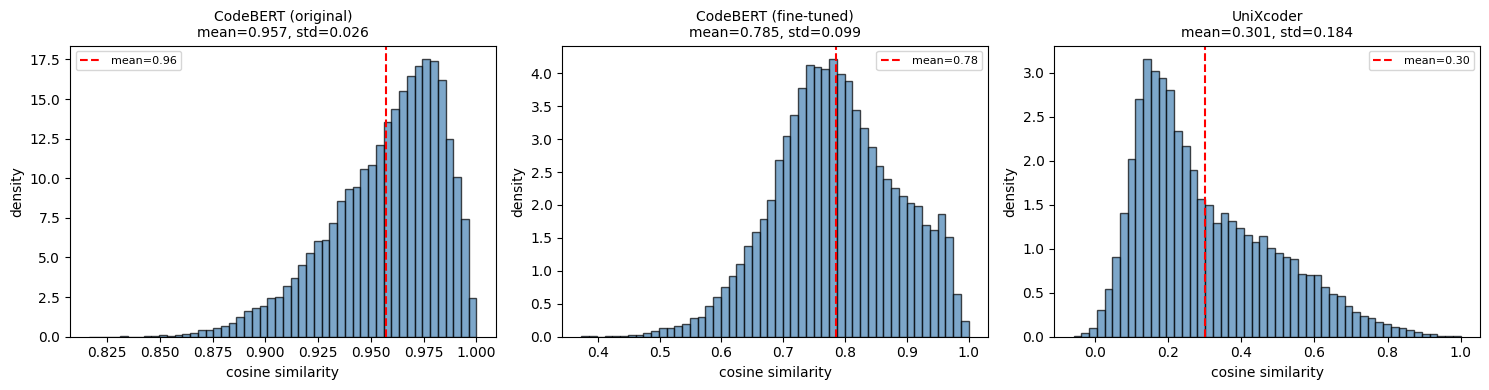

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

MAX_PAIRS_PER_PROJECT = 40000 # sample this many random pairs per project, otherwise the limit is the number of total nodes**2

def compute_embeddings_and_sample(json_path, tokenizer, model, model_name): # embeddings matrix and random pair similarities
    _, emb_matrix = embed_nodes_from_json(json_path, tokenizer, model, model_name)
    
    n = emb_matrix.shape[0]   
    max_possible = n*(n-1)//2
    num_pairs = min(MAX_PAIRS_PER_PROJECT, max_possible) # randomly sample pairs
    pairs = set()
    while len(pairs) < num_pairs:
        i = np.random.randint(0, n)
        j = np.random.randint(0, n)
        if i != j:
            pairs.add((min(i,j), max(i,j))) # store unordered generated pairs to avoid duplication
    
    pairs = list(pairs)
    i_vals = [p[0] for p in pairs]
    j_vals = [p[1] for p in pairs]
    sims = cosine_similarity(emb_matrix[i_vals], emb_matrix[j_vals]).diagonal()
    del emb_matrix
    gc.collect()
    return sims, n

all_stats = {name: {"sims": [], "total_nodes": 0} for name in models} # used to collect similarity statistics per model

for name, model_id in models.items():
    tokenizer, model = load_model(model_id)
    print(f"\n\n\nTokenizer and model loaded for {name}")
    for jf in json_files:
        json_path = Path(jf)
        project = json_path.parent.parent.name
        print(f"\nProject id: {project}")
        sims, node_count = compute_embeddings_and_sample(jf, tokenizer, model, name)
        all_stats[name]["sims"].extend(sims)
        all_stats[name]["total_nodes"] += node_count
        print(f"\t{node_count} nodes, {len(sims)} pairs")
    del model # unloading models
    del tokenizer

    torch.cuda.empty_cache()
    gc.collect()

fig, axs = plt.subplots(1, len(models), figsize=(15, 4))
for ax, (name, data) in zip(axs, all_stats.items()):
    sims = np.array(data["sims"])
    ax.hist(sims, bins=50, alpha=0.7, density=True, color='steelblue', edgecolor='black')
    ax.set_title(f"{name}\nmean={np.mean(sims):.3f}, std={np.std(sims):.3f}", fontsize=10)
    ax.set_xlabel("cosine similarity")
    ax.set_ylabel("density")
    ax.axvline(np.mean(sims), color='red', linestyle='--', label=f'mean={np.mean(sims):.2f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Visualizing an embedding based on natural language

In [13]:
# testing a user given note with UniXCoder which understands natural language
CHOSEN_MODEL_NAME = "UniXcoder"
chosen_model_id = models[CHOSEN_MODEL_NAME]
chosen_tokenizer, chosen_model = load_model(chosen_model_id)
note = "handles user login and session creation"
note_emb = get_code_embedding(note, chosen_tokenizer, chosen_model, False)
print(note_emb)
# no need to recompute embeddings for all nodes of the chosen model since they will be loaded from cache

cpu
[ 1.38116491e+00  2.22758457e-01 -2.56779343e-01  1.14102268e+00
  1.76621035e-01  6.10016823e-01  1.35949814e+00 -1.16876639e-01
 -7.18926564e-02  6.70354187e-01 -7.41386056e-01 -1.09777486e+00
  5.92339098e-01  1.31969249e+00 -4.37350154e-01  1.39504790e+00
  5.26081026e-01 -3.55838388e-01 -6.09198213e-02  1.29758644e+00
  8.66942406e-01  4.74302977e-01 -2.38053054e-02  5.46633065e-01
 -3.37563455e-01  1.82706416e+00  7.42063105e-01  1.70021224e+00
 -7.70012677e-01 -2.38597393e-03 -1.33303809e+00  9.83218312e-01
 -2.27141094e+00  4.91205156e-01 -6.73573971e-01 -1.54231513e+00
 -7.49731541e-01 -4.85201418e-01 -2.18419924e-01 -1.28467107e+00
 -9.06719506e-01  8.07328284e-01  5.65809123e-02  1.51743650e-01
 -5.51362693e-01 -3.93842816e-01  1.35198402e+00 -1.45215762e+00
 -2.14730486e-01 -1.16794741e+00 -6.78917766e-03 -5.06708547e-02
  1.73178184e+00  1.21606076e+00  1.32284141e+00 -2.96306491e-01
 -1.69848099e-01 -9.01800156e-01  2.79027551e-01  1.38067156e-01
 -5.92652142e-01  2.8

### Converting into PyG objects
- the chosen model is UniXCoder
- for each graph a .pkl file containing a PyG Data object will be saved inside the preprocessed_graphs folder

In [14]:
def load_graph_bundle(pkl_path):
    with open(pkl_path, "rb") as f:
        bundle = pickle.load(f)

    # for older bundles that stored `Data` under the `data` key
    if "data" in bundle:
        data = bundle["data"]
        node_list = bundle.get("node_list", [])
        original = bundle.get("original_embeddings")
        if original is None and hasattr(data, "x"):
            try:
                original = data.x.detach().cpu().numpy()
            except Exception:
                original = None
        return data, node_list, original

    x = bundle["x"]
    edge_index = bundle["edge_index"]
    data = Data(x=x, edge_index=edge_index)
    node_list = bundle.get("node_list", [])
    original = bundle.get("original_embeddings")
    if original is None:
        try:
            original = x.detach().cpu().numpy()
        except Exception:
            original = None
    return data, node_list, original

OUTPUT_DIR = "preprocessed_graphs" # where .pkl files will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)
# most GNN libraries expect a specific graph data structure that includes node features and edge connectivity in a standardised tensor format
def build_homogeneous_graph(edges, id_to_idx): # combining the CALLS and USES edges into a general association between nodes, since they both describe a relationship between functions
    edge_pairs = []
    for edge in edges:
        src = id_to_idx.get(edge["from"])
        dst = id_to_idx.get(edge["to"])
        if src is None or dst is None:
            continue
        edge_pairs.append([src, dst])
        edge_pairs.append([dst, src]) # undirected
    if not edge_pairs:
        return torch.empty((2, 0), dtype=torch.long)
    edge_index = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()
    return edge_index

def json_to_pyg_data(json_path, valid_nodes, embeddings): # converting json + embeddings to PyG data object
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    edges = data["graph"]["edges"]
    id_to_idx = {node["id"]: i for i, node in enumerate(valid_nodes)}
    edge_index = build_homogeneous_graph(edges, id_to_idx)
    x = torch.tensor(embeddings, dtype=torch.float)
    return Data(x=x, edge_index=edge_index), valid_nodes

# the same as before
for index, jf in enumerate(json_files):
    print(f"\n[{index+1}/{len(json_files)}] Processing: {jf}")
    valid_nodes, emb_matrix = embed_nodes_from_json(jf, chosen_tokenizer, chosen_model, CHOSEN_MODEL_NAME) # UniXcoder

    pyg_data, node_list = json_to_pyg_data(jf, valid_nodes, emb_matrix) # building Data type graph
    num_edges = pyg_data.edge_index.shape[1]
    print(f"Built graph: {pyg_data.x.shape[0]} nodes, {num_edges} undirected edges")
    
    base_name = os.path.basename(jf).replace(".json", "")
    path_hash = hashlib.md5(jf.encode()).hexdigest()[:12]
    out_file = os.path.join(OUTPUT_DIR, f"{base_name}_{path_hash}.pkl") # saving all info about nodes of a certain project graph into a single .pkl file
    
    with open(out_file, "wb") as f:
        pickle.dump({
            # "data": pyg_data, # PyG Data object with x embedding + edge_index undirected edges
            "x": pyg_data.x.detach().cpu(), # torch.Tensor (N, 768)
            "edge_index": pyg_data.edge_index.detach().cpu(), # torch.LongTensor (2, E)
            "node_list": node_list, # list of node dicts
            "json_path": jf, # original json path
            "original_embeddings": emb_matrix # (num_nodes, 768) codebert features
        }, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved to: {out_file}")
    print(f"Pickle keys: {['x', 'edge_index', 'node_list', 'json_path', 'original_embeddings']}")

print(f"Preprocessing is complete, the .pkl files saved in: {OUTPUT_DIR}")

del chosen_model, chosen_tokenizer
torch.cuda.empty_cache()
gc.collect()


[1/1] Processing: C:\Users\alice\AppData\Roaming\log-a-priori-desktop-shell\qntdp9a3y37m8l7\analysis\ts-code-graph.json
Built graph: 373 nodes, 2556 undirected edges
Saved to: preprocessed_graphs\ts-code-graph_410adac1e0ec.pkl
Pickle keys: ['x', 'edge_index', 'node_list', 'json_path', 'original_embeddings']
Preprocessing is complete, the .pkl files saved in: preprocessed_graphs


82

In [15]:
pkl_file = Path("preprocessed_graphs/ts-code-graph_2e716a581f37.pkl")
with open(pkl_file, "rb") as f:
    obj = pickle.load(f)

print("Type:", type(obj))
print("Content preview:", obj)
if isinstance(obj, dict):
    print("Keys:", obj.keys())
elif hasattr(obj, '__dict__'):
    print("Attributes:", obj.__dict__.keys())

Type: <class 'dict'>
Content preview: {'x': tensor([[ 0.5727,  0.6115,  2.4320,  ...,  1.8645, -0.8942, -2.2295],
        [ 0.6881, -0.4984, -0.6729,  ...,  0.6782,  0.9687, -0.5949],
        [-0.6588,  0.1092,  0.5279,  ...,  0.8453,  0.5033, -1.1325],
        ...,
        [ 0.6921,  0.1088,  1.6506,  ...,  0.9895,  1.1655, -1.4152],
        [ 0.0806,  0.7130,  0.9506,  ...,  0.3763,  1.0429, -1.3923],
        [ 0.0686,  0.6766,  0.9757,  ...,  0.3406,  1.0467, -1.4046]]), 'edge_index': tensor([[ 1,  7,  4,  8, 10,  9, 11, 10, 14,  8, 15,  8, 16,  8, 18,  8, 19,  8,
         20,  8, 22,  7, 22, 28, 23, 26, 23, 31, 24,  7, 24, 37, 25, 35, 25, 39,
         33,  7, 33, 30, 33, 29, 33, 28, 34, 27, 42,  7, 42, 40, 42, 38, 42, 37,
         43, 36, 45,  7, 45, 30, 45, 29, 45, 28, 46, 27,  0, 11,  0, 12,  0, 21,
          1,  7,  3,  2,  3,  5,  3,  6,  4,  8,  5,  4,  7, 14,  7, 15, 10,  9,
         11, 10, 12, 34, 12, 46, 12, 33, 12, 45, 12, 43, 12, 42, 13,  3, 14,  8,
         15,  8, 16, 

## Generating natural language queries
- for a chosen project

In [ ]:
from pathlib import Path
import json
import pickle
import re
import numpy as np
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
QUERIES_JSON = "nl_queries.json"
EVAL_PROJECT_PKL = "preprocessed_graphs/ts-code-graph_410adac1e0ec.pkl"
pkl_path = Path(EVAL_PROJECT_PKL)
queries_path = Path(QUERIES_JSON)

SUMMARIZER_MODEL_NAME = "habuiphuc/codet5-code-summarization"
REGENERATE_QUERIES = True # set True to overwrite existing file
MAX_QUERIES = 60 # final number of query, node_id pairs to write
SEED = 42
MAX_CODE_CHARS = 4000
SUM_MAX_INPUT_TOKENS = 512 # further truncation
SUM_MAX_NEW_TOKENS = 48 # the generated summary length
SUM_NUM_BEAMS = 4 # for beam search
SUM_BATCH_SIZE = 8 # SUM_BATCH_SIZE functions at a time
CANDIDATE_MULTIPLIER = 2 # summarize up to MAX_QUERIES*CANDIDATE_MULTIPLIER and keep best MAX_QUERIES

def ensure_unixcoder_loaded(): # loading the UniXcoder tokenizer and model only once, reusing them across all embedding calls during query generation and retrieval evaluation
    global tokenizer, nl_encoder
    if 'tokenizer' in globals() and 'nl_encoder' in globals():
        return
    from transformers import AutoTokenizer, AutoModel
    unixcoder_name = 'microsoft/unixcoder-base'
    tokenizer = AutoTokenizer.from_pretrained(unixcoder_name)
    nl_encoder = AutoModel.from_pretrained(unixcoder_name).to(DEVICE)
    nl_encoder.eval()

def masked_mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype) # expand shape to the same shape as the hidden state
    summed = (last_hidden_state * mask).sum(dim=1) # sum of real tokens
    denom = mask.sum(dim=1).clamp(min=1.0) # number of real tokens
    return summed/denom # mean pool

def embed_unixcoder_texts(texts, max_len=512, batch_size=32): # encoding a list of nl texts into UniXCoder embeddings using mean pooling
    ensure_unixcoder_loaded()
    out = []
    nl_encoder.eval()
    with torch.inference_mode():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(DEVICE)
            outputs = nl_encoder(**inputs)
            pooled = masked_mean_pool(outputs.last_hidden_state, inputs['attention_mask'])
            out.append(pooled.cpu().numpy().astype(np.float32))
    return np.vstack(out) # dim (len(texts), 768)

def cosine_sim_rows(a, b, eps=1e-12):
    a = a.astype(np.float32, copy=False)
    b = b.astype(np.float32, copy=False)
    a_norm = np.maximum(np.linalg.norm(a, axis=1, keepdims=True), eps)
    b_norm = np.maximum(np.linalg.norm(b, axis=1, keepdims=True), eps)
    return ((a/a_norm)*(b/b_norm)).sum(axis=1) # computing cosine similarity between corresponding rows of two matrices

def load_summarizer(model_name: str): # seq2seq summarization
    from transformers import AutoTokenizer as SumTokenizer, AutoModelForSeq2SeqLM
    sum_tokenizer = SumTokenizer.from_pretrained(model_name)
    sum_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(DEVICE)
    sum_model.eval()
    return sum_tokenizer, sum_model

def summarize_prompts(prompts, sum_tokenizer, sum_model): # running the seq2seq summarizer on a list of code prompts
    summaries = []
    with torch.inference_mode():
        for i in range(0, len(prompts), SUM_BATCH_SIZE):
            batch = prompts[i:i+SUM_BATCH_SIZE]
            inputs = sum_tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=SUM_MAX_INPUT_TOKENS).to(DEVICE)
            gen_ids = sum_model.generate(**inputs, max_new_tokens=SUM_MAX_NEW_TOKENS, num_beams=SUM_NUM_BEAMS, early_stopping=True)
            texts = sum_tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
            summaries.extend([t.strip() for t in texts])
    return summaries

if queries_path.exists() and not REGENERATE_QUERIES:
    print(f"Queries file already exists at {queries_path}, set REGENERATE_QUERIES=True to overwrite")
else:
    print(f"Loading graph bundle: {pkl_path}")
    data, node_list, _ = load_graph_bundle(pkl_path)
    raw_emb = data.x.detach().cpu().numpy().astype(np.float32) # pre computed UniXcoder embeddings of all code nodes

    candidate_indices = [i for i, node in enumerate(node_list) if node.get('code') and (node.get('kind') in {"function", "method"})]
    print(f"Candidate nodes: {len(candidate_indices)}")
    
    # seq2seq: summarize code using CodeT5 for selected nodes
    n_candidates = min(len(candidate_indices), max(MAX_QUERIES, MAX_QUERIES*CANDIDATE_MULTIPLIER))
    rng = np.random.default_rng(SEED)
    selected = rng.choice(candidate_indices, size=n_candidates, replace=False).tolist()

    print(f"Summarizing {len(selected)} nodes with {SUMMARIZER_MODEL_NAME} (first run downloads the model)")
    sum_tokenizer, sum_model = load_summarizer(SUMMARIZER_MODEL_NAME)
    prompts = []
    selected_ids = []
    for i in selected:
        node = node_list[i]
        code = (node.get('code') or '').strip()
        if len(code) > MAX_CODE_CHARS:
            code = code[:MAX_CODE_CHARS]
        prompts.append(code)
        selected_ids.append(node['id'])
    query_texts = summarize_prompts(prompts, sum_tokenizer, sum_model)
    query_texts = [re.sub(r'\s+', ' ', q).strip() for q in query_texts]

    # keeping the summaries that are most aligned with the raw code embeddings
    q_emb = embed_unixcoder_texts(query_texts)
    code_emb = raw_emb[np.array(selected)]
    sims = cosine_sim_rows(q_emb, code_emb)
    ranked = sorted(zip(selected, selected_ids, query_texts, sims), key=lambda x: float(x[3]), reverse=True)
    ranked = ranked[:MAX_QUERIES] # trimming to MAX_QUERIES
    selected = [i for i, _, _, _ in ranked]
    selected_ids = [nid for _, nid, _, _ in ranked]
    query_texts = [qt for _, _, qt, _ in ranked]
    print(f"Selected top {len(query_texts)} summaries by UniXcoder similarity")

    queries = {}
    for idx, (q, node_id) in enumerate(zip(query_texts, selected_ids)):
        q = (q or '').strip()
        if not q:
            continue
        if q in queries:
            node = node_list[selected[idx]]
            file_name = Path(node.get('filePath','')).name
            simple = node.get('simpleName') or node.get('name') or ''
            suffix = f" ({simple or file_name})"
            q2 = q + suffix
            n = 2
            while q2 in queries:
                q2 = f"{q}{suffix} #{n}"
                n += 1
            q = q2 # deduplicating keys
        queries[q] = node_id

    with queries_path.open('w', encoding='utf-8') as f:
        json.dump(queries, f, indent=2, ensure_ascii=False)
    print(f"Wrote {len(queries)} queries to: {queries_path}")
    print("Sample:")
    for k, v in list(queries.items())[:5]:
        print("\t", k, "=>", v)

Loading graph bundle: preprocessed_graphs\ts-code-graph_410adac1e0ec.pkl
Candidate nodes: 319
Summarizing 120 nodes with habuiphuc/codet5-code-summarization (first run downloads the model)
Selected top 60 summaries by UniXcoder similarity
Wrote 60 queries to: nl_queries.json
Sample:
	 returns a key for the node declaration in the source file, the line it is first defined in the source file => entity:full-project:C:/Users/alice/Documents/Log-a-Priori/workflow-app/scripts/ts-ast-tree.js:3065:function:declarationKey
	 Use this method to create a value component for SelectPrimitive.Value with the given props. For example. The default implementation returns a primitive value with the specified data-slot for the value. => entity:full-project:C:/Users/alice/Documents/Log-a-Priori/workflow-app/components/ui/select.tsx:528:function:SelectValue
	 resolve from environment file and return value from parsed dotenv envPath: environment path key: environment key => entity:full-project:C:/Users/alice/

## Deep Graph InfoMax

- trying to maximize mutual information between local node representations and a global graph summary using GCN
- loading preprocessed PyG Data objects where the node features are the UniXcoder embeddings
- training a 2 layer GCN encoder + discriminator
- DGI loss function

In [27]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import json
from torch_geometric.utils import scatter
import numpy as np
from pathlib import Path
from collections import defaultdict, deque
from sklearn.linear_model import Ridge

PREPROCESSED_DIR = "preprocessed_graphs"
UNIVERSAL_MODEL_PATH = "dgi_encoder_universal.pt" # the single model file

HIDDEN_CHANNELS = 256
OUT_CHANNELS = 512
EPOCHS = 100
BATCH_SIZE = 2 # number of graphs per batch
LR = 1e-3

PREPROCESSED_DIR = Path("preprocessed_graphs")
UNIVERSAL_MODEL_PATH = "dgi_encoder_universal.pt"

unixcoder_name = "microsoft/unixcoder-base"
tokenizer = AutoTokenizer.from_pretrained(unixcoder_name)
nl_encoder = AutoModel.from_pretrained(unixcoder_name).to(DEVICE)
nl_encoder.eval()

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(51416, 768, padding_idx=1)
    (position_embeddings): Embedding(1026, 768, padding_idx=1)
    (token_type_embeddings): Embedding(10, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (

### GCN encoder

In [18]:
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # initial approach: a two layer GCN only sees immediate neighbours
        self.conv1 = GCNConv(in_channels, hidden_channels) # takes x, edge_index and outputs node embeddings denoted by h 
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu() # h_conv1 = sigma_activation(a_tilde*X*W_0) where a' = normalized adjancency matrix with self loops
        x = self.conv2(x, edge_index) # h_conv2 = a'*h_conv1*W_1
        return x

### Discriminator and corruption methods

In [19]:
class Discriminator(nn.Module): # discriminator = a bilinear scorer between node embedding h_i and a global summary vector s
    def __init__(self, channels):
        super().__init__()
        self.bilinear = nn.Bilinear(in1_features=channels, in2_features=channels, out_features=1) # a function that maps inputs to outputs using a linear mapping for each input vector independently
        # computes a scalar h_i^T*W*s + b

    def forward(self, h, s):
        # h: (N, channels)
        # s is copied for the bilinear layer
        if s.dim() == 1: # detects single summary case and expands it to (N, channels) to match the bilinear input requirements
            s = s.unsqueeze(0).repeat(h.size(0), -1) # s: (channels,) => (N, channels) determined by repeat, where N is the number of nodes and channels is the output dimension of the encoder
        # now s is (N, channels) in all cases
        return self.bilinear(h, s) # the bilinear(h_i, s) score => (N, 1)

def corruption(x, edge_index, batch): # shuffling the feature vectors among nodes
    # shuffling node features within each graph, but keeping the graph structure and batch unmodified
    # in the single graph case we simply permute the rows of X
    # in the batched case we must permute only within each individual graph, otherwise features would be mixed from unrelated subgraphs
    # PyG's Batch object stores the boundaries of each subgraph in batch.ptr, used to restrict the permutation to the slice of x belonging to each graph

    x_corr = x.clone()
    for i in range(batch.num_graphs): # trying to retrieve the node range for graph i
        if i == 0:
            start = 0
        else:
            start = batch.ptr[i].item()
        end = batch.ptr[i + 1].item()

        perm = torch.randperm(end-start, device=x.device) # shuffle x row wise to create a fake feature matrix, with the intention to keep edge_index unchanged
        # (X, A) => (X[perm], A) = (X_tilde, A), the adjancency matrix remains unchanged
         
        x_corr[start:end] = x_corr[start + perm] # applying the permutation to the node slice part of graph i

    return x_corr, edge_index # will be used to then obtain corrupted node embeddings h_tilde = GCN(X_tilde, A)

### Loss method

In [20]:
# i want the dgi to learn to make each node embedding predictive of its own graph’s global summary
def dgi_loss(encoder, discriminator, data): # binary cross‑entropy that encourages bilinear(h_i, s) to be high for real nodes and low for corrupted ones
    x = data.x
    edge_index = data.edge_index
    batch_vec = data.batch # (total_nodes,) batch is a tensor assigning each node to a graph index

    h = encoder(x, edge_index)
    s = scatter(h, batch_vec, dim=0, reduce='mean') # the mean of the sum of all node embeddings for each graph, s: (num_graphs, channels)
    logits_real = discriminator(h, s[batch_vec]) # multiple graphs are batched, each node gets its own graph's summary via s[batch]

    # corruption needs the whole data object to access .ptr and .num_graphs
    x_corr, _ = corruption(x, edge_index, data)
    h_corr = encoder(x_corr, edge_index)
    logits_fake = discriminator(h_corr, s[batch_vec])

    bce = nn.BCEWithLogitsLoss()
    # log(y_hat) remains => as close to 1 as possible, log(1-y_hat) => as close to 0
    # real nodes, the actual patch representations h_i and the global summary s => the discriminator outputs a high probability, label 1
    # corrupted nodes, h_corr generated from a shuffled feature matrix => the discriminator outputs a low probability, label 0
    loss_dgi = bce(logits_real, torch.ones_like(logits_real)) + bce(logits_fake, torch.zeros_like(logits_fake))

    return loss_dgi

### Training
- for 2 projects

Loaded 2 projects, feature dim: 768
Training the DGI model...
	epoch 020, avg loss: 1.2839
	epoch 040, avg loss: 1.1543
	epoch 060, avg loss: 0.8407
	epoch 080, avg loss: 0.2821
	epoch 100, avg loss: 0.2414
Universal encoder saved to dgi_encoder_universal.pt


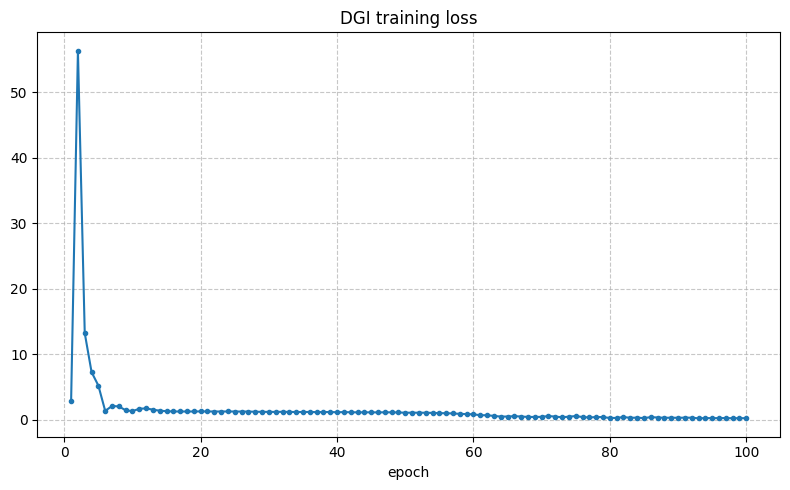

In [32]:
project_graphs = []
for pkl_file in PREPROCESSED_DIR.glob("*.pkl"):
    data, node_list, original = load_graph_bundle(pkl_file)

    project_graphs.append(data)

print(f"Loaded {len(project_graphs)} projects, feature dim: {project_graphs[0].x.size(1)}")
in_channels = project_graphs[0].x.size(1)

loader = DataLoader(project_graphs, batch_size=BATCH_SIZE, shuffle=True)

encoder = GCNEncoder(in_channels, HIDDEN_CHANNELS, OUT_CHANNELS).to(DEVICE)
discriminator = Discriminator(OUT_CHANNELS).to(DEVICE)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(discriminator.parameters()), lr=LR)

epoch_losses = [] # storing the average loss per epoch
print("Training the DGI model...")
for epoch in range(1, EPOCHS+1):
    encoder.train()
    discriminator.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss = dgi_loss(encoder, discriminator, batch) # pass the whole Data batch object
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(project_graphs)
    epoch_losses.append(avg_loss)
    if epoch % 20 == 0:
        print(f"\tepoch {epoch:03d}, avg loss: {avg_loss:.4f}")

torch.save(encoder.state_dict(), UNIVERSAL_MODEL_PATH)
print(f"Universal encoder saved to {UNIVERSAL_MODEL_PATH}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker='o', markersize=3, linewidth=1.5)
plt.xlabel("epoch")
plt.title("DGI training loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Comparing DGI and UniXcoder embeddings for natural language queries
- retrieves connected clusters of nodes that are semantically relevant to a query

In [33]:
def embed_query_unixcoder(text): # similiar to above but only for one query: mean pool UniXcoder embedding for a natural language query
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        outputs = nl_encoder(**inputs)
    emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy().astype(np.float32)
    return emb.squeeze(0)

def get_connected_component(start_node, edge_index, max_size=None):
    edge_index_np = edge_index.cpu().numpy()
    adj = defaultdict(set)
    for src, dst in edge_index_np.T:
        adj[int(src)].add(int(dst))
        adj[int(dst)].add(int(src))
    visited = set()
    queue = deque([start_node])
    visited.add(start_node)
    while queue:
        if max_size and len(visited) >= max_size:
            break
        node = queue.popleft()
        for neighbor in adj[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return visited

def filter_by_connectivity(node_indices, edge_index):
    components = {}
    visited_global = set()
    comp_id = 0
    for node_idx in node_indices:
        if node_idx in visited_global:
            continue
        component = get_connected_component(node_idx, edge_index)
        filtered = component & set(node_indices)
        if filtered:
            components[comp_id] = filtered
            visited_global.update(filtered)
            comp_id += 1
    return components

def retrieve_clusters(embeddings, node_names, edge_index, query_embedding, top_k=20, similarity_threshold=0.5):
    sims = cosine_similarity([query_embedding], embeddings)[0]
    top_indices = np.argsort(-sims)[:top_k]
    top_sims = sims[top_indices]
    candidates = [idx for idx, sim in zip(top_indices, top_sims) if sim >= similarity_threshold]
    components = filter_by_connectivity(candidates, edge_index)

    sim_dict = {
        'all_top_k': [(node_names[idx], float(sims[idx])) for idx in top_indices],
        'filtered_threshold': [(node_names[idx], float(sims[idx])) for idx in candidates]
    }
    comp_dict = {}
    for comp_id, comp_nodes in components.items():
        comp_dict[comp_id] = {
            'nodes': [node_names[i] for i in comp_nodes],
            'count': len(comp_nodes),
            'avg_similarity': float(np.mean([sims[i] for i in comp_nodes]))
        }
    return {
        'similarities': sim_dict,
        'connected_components': comp_dict,
        'total_connected_nodes': sum(len(c) for c in components.values()),
        'total_components': len(components)
    }

def compare_one_query(query_text, target_node_id, pkl_path): #  running DGI vs UniXcoder retrieval for a single query
    data, node_list, orig_embs = load_graph_bundle(pkl_path)
    edge_index = data.edge_index
    node_names = []
    id_to_idx = {}
    for i, node in enumerate(node_list):
        name = node.get('simpleName') or node.get('name') or f"node_{i}"
        node_names.append(name)
        id_to_idx[node['id']] = i

    if target_node_id not in id_to_idx:
        raise ValueError(f"Target node id {target_node_id} not found in graph")
    target_idx = id_to_idx[target_node_id]
    # true cluster = target itself + all direct neighbours (undirected)
    true_cluster = {target_idx}
    edge_np = edge_index.cpu().numpy()
    for src, dst in edge_np.T:
        if src == target_idx:
            true_cluster.add(int(dst))
        if dst == target_idx:
            true_cluster.add(int(src))
    
    if isinstance(orig_embs, np.ndarray): # UniXcoder node embeddings
        uni_emb = orig_embs.astype(np.float32)
    else:
        uni_emb = data.x.cpu().numpy().astype(np.float32)
    
    ckpt_path = Path(UNIVERSAL_MODEL_PATH)
    if ckpt_path.exists(): # DGI embeddings
        in_ch = data.num_features
        state = torch.load(ckpt_path, map_location=DEVICE)
        hc = state['conv1.lin.weight'].shape[0]
        oc = state['conv2.lin.weight'].shape[0]
        encoder_dgi = GCNEncoder(in_ch, hc, oc).to(DEVICE)
        encoder_dgi.load_state_dict(state)
        encoder_dgi.eval()
        with torch.no_grad():
            dgi_emb_raw = encoder_dgi(data.x.to(DEVICE), edge_index.to(DEVICE)).cpu().numpy()
    else:
        print(f"Warning: {ckpt_path} not found, using UniXcoder features as DGI")
        dgi_emb_raw = data.x.cpu().numpy()

    if dgi_emb_raw.shape[1] != 768:
        reg = Ridge(alpha=1.0, fit_intercept=True)
        reg.fit(dgi_emb_raw, uni_emb)
        dgi_emb = reg.predict(dgi_emb_raw).astype(np.float32)
    else:
        dgi_emb = dgi_emb_raw

    q_emb = embed_query_unixcoder(query_text)

    # retrieving for both methods
    dgi_res = retrieve_clusters(dgi_emb, node_names, edge_index, q_emb, top_k=20, similarity_threshold=0.3)
    uni_res = retrieve_clusters(uni_emb, node_names, edge_index, q_emb, top_k=20, similarity_threshold=0.3)

    dgi_retrieved_idx = set() # compute retrieved sets as node indices for accuracy evaluation
    for comp in dgi_res['connected_components'].values():
        for name in comp['nodes']:
            idx = node_names.index(name)
            dgi_retrieved_idx.add(idx)
    uni_retrieved_idx = set() # same here
    for comp in uni_res['connected_components'].values():
        for name in comp['nodes']:
            idx = node_names.index(name)
            uni_retrieved_idx.add(idx)

    def accuracy_metrics(retrieved, true): # computing recall, precision, f1
        inter = retrieved & true
        recall = len(inter)/len(true) if len(true) > 0 else 0.0
        precision = len(inter)/len(retrieved) if len(retrieved) > 0 else 0.0
        f1 = 2 * precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
        return recall, precision, f1

    rec_dgi, prec_dgi, f1_dgi = accuracy_metrics(dgi_retrieved_idx, true_cluster)
    rec_uni, prec_uni, f1_uni = accuracy_metrics(uni_retrieved_idx, true_cluster)

    overlap = dgi_retrieved_idx & uni_retrieved_idx
    union = dgi_retrieved_idx | uni_retrieved_idx
    overlap_pct = len(overlap)/len(union)*100 if union else 0.0

    return {
        'query': query_text,
        'target_node': target_node_id,
        'true_cluster_size': len(true_cluster),
        'dgi_total_nodes': dgi_res['total_connected_nodes'],
        'dgi_components': dgi_res['total_components'],
        'uni_total_nodes': uni_res['total_connected_nodes'],
        'uni_components': uni_res['total_components'],
        'overlap_nodes': len(overlap),
        'overlap_pct': overlap_pct,
        'dgi_recall': rec_dgi,
        'dgi_precision': prec_dgi,
        'dgi_f1': f1_dgi,
        'uni_recall': rec_uni,
        'uni_precision': prec_uni,
        'uni_f1': f1_uni,
        'dgi_details': dgi_res,
        'uni_details': uni_res,
        'dgi_retrieved_idx': dgi_retrieved_idx,
        'uni_retrieved_idx': uni_retrieved_idx,
        'true_cluster_idx': true_cluster
    }

with open(QUERIES_JSON, 'r') as f:
    all_queries = json.load(f)
queries_list = list(all_queries.items())
print(f"Total queries in file: {len(queries_list)}")

# quick testing
# MAX_QUERIES_TO_RUN = None
# if MAX_QUERIES_TO_RUN:
#     queries_list = queries_list[:MAX_QUERIES_TO_RUN]

results_summary = []

for idx, (q_text, target_node_id) in enumerate(queries_list):
    print(f"Query {idx+1}/{len(queries_list)}: {q_text}")
    print(f"Target node id: {target_node_id}")
    res = compare_one_query(q_text, target_node_id, EVAL_PROJECT_PKL)
    results_summary.append(res)

    dgi = res['dgi_details']
    print("\nDGI results")
    print(f"Total connected nodes: {dgi['total_connected_nodes']} in {dgi['total_components']} component(s)")
    print(f"Top candidates:")
    for name, sim in dgi['similarities']['all_top_k']:
        print(f"\t{name:25s} -> {sim:.4f}")
    if dgi['connected_components']:
        print(f"\nConnected components:")
        for cid, cdata in sorted(dgi['connected_components'].items()):
            print(f"\tComponent {cid} ({cdata['count']} nodes, avg sim={cdata['avg_similarity']:.4f}):")
            for n in sorted(cdata['nodes']):
                print(f"\t- {n}")
    else:
        print("\tNo components after similarity threshold")
    print(f"Accuracy: recall={res['dgi_recall']:.4f}, precision={res['dgi_precision']:.4f}, f1={res['dgi_f1']:.4f}")

    uni = res['uni_details']
    print("\nUniXCoder results")
    print(f"Total connected nodes: {uni['total_connected_nodes']} in {uni['total_components']} component(s)")
    print(f"Top candidates:")
    for name, sim in uni['similarities']['all_top_k']:
        print(f"\t{name:25s} -> {sim:.4f}")
    if uni['connected_components']:
        print(f"\nConnected components:")
        for cid, cdata in sorted(uni['connected_components'].items()):
            print(f"\tComponent {cid} ({cdata['count']} nodes, avg sim={cdata['avg_similarity']:.4f}):")
            for n in sorted(cdata['nodes']):
                print(f"\t- {n}")
    else:
        print("\tNo components after similarity threshold")
    print(f"Accuracy: recall={res['uni_recall']:.4f}, precision={res['uni_precision']:.4f}, f1={res['uni_f1']:.4f}")

    print("\nOverlap and accuracy summary")
    print(f"\tcluster size: {res['true_cluster_size']}")
    print(f"\tDGI unique nodes: {len(res['dgi_retrieved_idx'] - res['uni_retrieved_idx'])}")
    print(f"\tUniXcoder unique nodes: {len(res['uni_retrieved_idx'] - res['dgi_retrieved_idx'])}")
    print(f"\tintersection: {res['overlap_nodes']} nodes")
    print(f"\toverlap: {res['overlap_pct']:.1f}% of union")

print()
print("Aggregated metrics (mean +/- std across all queries)")
arr_fields = {
    'DGI total nodes': [r['dgi_total_nodes'] for r in results_summary],
    'UniXcoder total nodes': [r['uni_total_nodes'] for r in results_summary],
    'overlap': [r['overlap_pct'] for r in results_summary],
    'DGI recall': [r['dgi_recall'] for r in results_summary],
    'UniXcoder recall': [r['uni_recall'] for r in results_summary],
    'DGI precision': [r['dgi_precision'] for r in results_summary],
    'UniXcoder precision': [r['uni_precision'] for r in results_summary],
    'DGI f1': [r['dgi_f1'] for r in results_summary],
    'UniXcoder f1': [r['uni_f1'] for r in results_summary],
}
for metric, values in arr_fields.items():
    print(f"\t{metric:25s}: {np.mean(values):.4f} +/- {np.std(values):.4f}")

Total queries in file: 60
Query 1/60: returns a key for the node declaration in the source file, the line it is first defined in the source file
Target node id: entity:full-project:C:/Users/alice/Documents/Log-a-Priori/workflow-app/scripts/ts-ast-tree.js:3065:function:declarationKey

DGI results
Total connected nodes: 15 in 1 component(s)
Top candidates:
	declarationKey            -> 0.6643
	resolveCallTarget         -> 0.5682
	extractCallEdges          -> 0.5199
	analyzeFullProject        -> 0.4699
	getStartLocation          -> 0.4628
	getEndLocation            -> 0.4619
	toVisualizationNode       -> 0.4216
	fileOf                    -> 0.4052
	buildEntityContext        -> 0.4045
	getFunctionDisplayName    -> 0.3964
	buildEntityId             -> 0.3791
	buildVisualization        -> 0.3648
	getRepoRelativePath       -> 0.3570
	safeSignature             -> 0.3015
	analyzeCommitDirectory    -> 0.3007
	extractUsesEdges          -> 0.2913
	extractModuleImportEdges  -> 0.2889
	extractJsxCom